<a href="https://colab.research.google.com/github/nehabellale-boop/ANNDL_Project/blob/main/Rn76CAI2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import BernoulliRBM

# Download dataset
path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

# Find CSV files inside folders
csv_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

# Load first CSV (limit rows)
file_path = csv_files[0]
df = pd.read_csv(file_path, nrows=300000)

print("Using file:", file_path)
print(df.head())

Using Colab cache for faster access to the 'ecommerce-behavior-data-from-multi-category-store' dataset.
Using file: /kaggle/input/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
                event_time event_type  product_id          category_id  \
0  2019-11-01 00:00:00 UTC       view     1003461  2053013555631882655   
1  2019-11-01 00:00:00 UTC       view     5000088  2053013566100866035   
2  2019-11-01 00:00:01 UTC       view    17302664  2053013553853497655   
3  2019-11-01 00:00:01 UTC       view     3601530  2053013563810775923   
4  2019-11-01 00:00:01 UTC       view     1004775  2053013555631882655   

               category_code   brand   price    user_id  \
0     electronics.smartphone  xiaomi  489.07  520088904   
1  appliances.sewing_machine  janome  293.65  530496790   
2                        NaN   creed   28.31  561587266   
3  appliances.kitchen.washer      lg  712.87  518085591   
4     electronics.smartphone  xiaomi  183.27  558856683   

       

Cleaned Shape: (5512, 9)


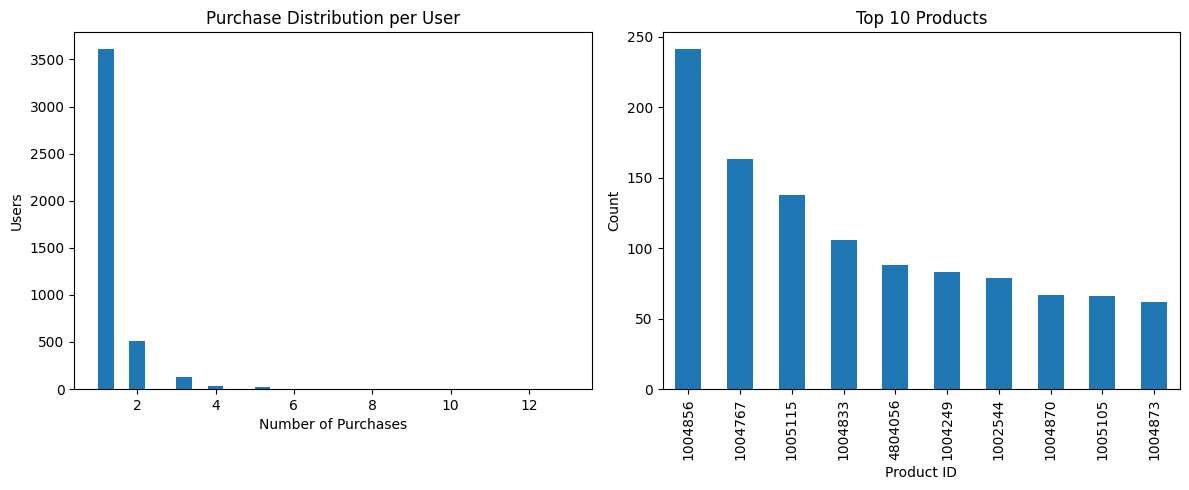

In [ ]:
# Keep only purchases
df = df[df['event_type'] == 'purchase']

# Clean data
df = df.dropna(subset=['user_id', 'product_id'])
df['user_id'] = df['user_id'].astype(int)
df['product_id'] = df['product_id'].astype(int)

print("Cleaned Shape:", df.shape)

# Prepare data
user_purchases = df.groupby('user_id').size()
top_products = df['product_id'].value_counts().head(10)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graph 1: Purchase distribution
axes[0].hist(user_purchases, bins=30)
axes[0].set_title("Purchase Distribution per User")
axes[0].set_xlabel("Number of Purchases")
axes[0].set_ylabel("Users")

# Graph 2: Top 10 products
top_products.plot(kind='bar', ax=axes[1])
axes[1].set_title("Top 10 Products")
axes[1].set_xlabel("Product ID")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Matrix Shape: (4334, 2151)


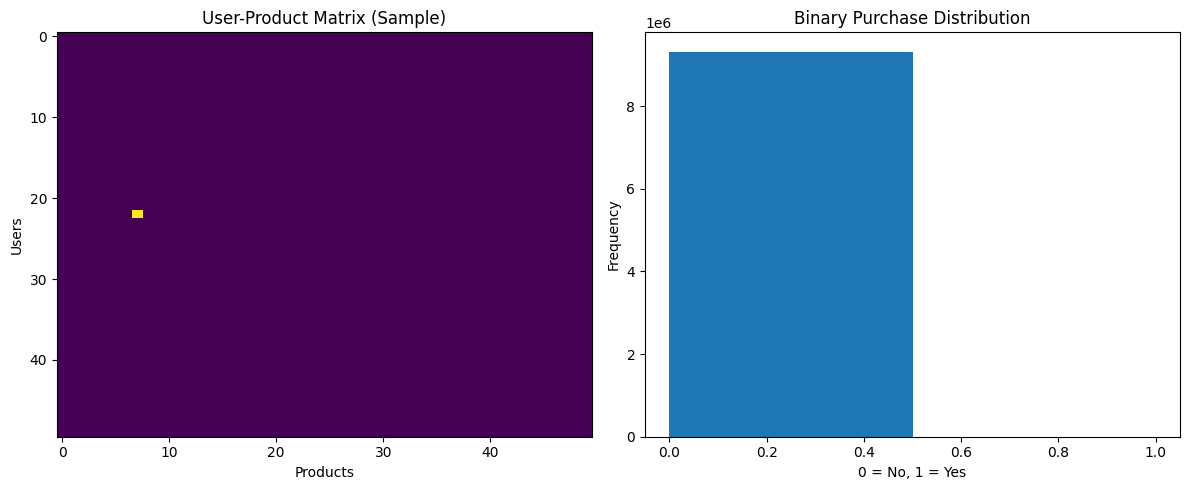

In [ ]:
# Create User-Product Matrix
customer_item = pd.crosstab(df['user_id'], df['product_id'])

print("Matrix Shape:", customer_item.shape)

# Normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
customer_item_scaled = scaler.fit_transform(customer_item)

# Convert to binary
customer_item_binary = (customer_item_scaled > 0).astype(int)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graph 3: Matrix visualization
axes[0].imshow(customer_item.iloc[:50, :50], aspect='auto')
axes[0].set_title("User-Product Matrix (Sample)")
axes[0].set_xlabel("Products")
axes[0].set_ylabel("Users")

# Graph 4: Binary distribution
axes[1].hist(customer_item_binary.flatten(), bins=2)
axes[1].set_title("Binary Purchase Distribution")
axes[1].set_xlabel("0 = No, 1 = Yes")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

RBM Training Completed


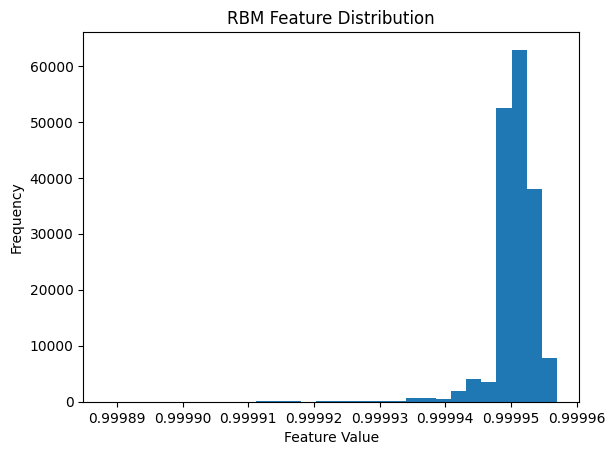

Average feature value: 0.9999506075417947


In [ ]:
# Train-Test Split
X_train, X_test = train_test_split(customer_item_binary, test_size=0.2, random_state=42)

# Train RBM
rbm = BernoulliRBM(n_components=50, n_iter=10, random_state=42)
rbm.fit(X_train)

print("RBM Training Completed")

# Transform data
train_transformed = rbm.transform(X_train)

# 🔥 Graph 5: RBM learned features
plt.figure()
plt.hist(train_transformed.flatten(), bins=30)
plt.title("RBM Feature Distribution")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()

# 🔥 EXTRA: Average feature activation
print("Average feature value:", train_transformed.mean())